In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("restaurant_deliveries.csv")
df

,Order Date,Customer Location Latitude,Customer Location Longitude
0,2024-10-30,-64.422765,-104.314848
1,2024-11-06,38.715505,-93.664296
2,2024-03-28,-82.208504,-13.563827
3,2024-11-24,88.750964,44.094277
4,2024-10-11,53.461366,-56.535313
...,...,...,...
49995,2024-07-31,16.003230,-110.385825
49996,2024-08-23,-51.499978,60.187253
49997,2024-02-14,-56.227167,137.400090
49998,2024-04-28,70.467715,-20.828838


In [3]:
scaler = StandardScaler()
df[["Latitude_Scaled", "Longitude_Scaled"]] = scaler.fit_transform(df[["Customer Location Latitude", "Customer Location Longitude"]])
df

,Order Date,Customer Location Latitude,Customer Location Longitude,Latitude_Scaled,Longitude_Scaled
0,2024-10-30,-64.422765,-104.314848,-1.257365,-0.980006
1,2024-11-06,38.715505,-93.664296,0.712035,-0.877383
2,2024-03-28,-82.208504,-13.563827,-1.596979,-0.105578
3,2024-11-24,88.750964,44.094277,1.667450,0.449985
4,2024-10-11,53.461366,-56.535313,0.993603,-0.519628
...,...,...,...,...,...
49995,2024-07-31,16.003230,-110.385825,0.278350,-1.038502
49996,2024-08-23,-51.499978,60.187253,-1.010607,0.605048
49997,2024-02-14,-56.227167,137.400090,-1.100872,1.349029
49998,2024-04-28,70.467715,-20.828838,1.318336,-0.175579


In [4]:
def find_best_k(data, max_k):
    silhouette_scores = []
    kmeans_optimal_labels = []
    for k in range(2, max_k+1):
        kmeans_optimal = KMeans(n_clusters=k)
        kmeans_optimal.fit(data)
        kmeans_optimal_labels.append((k, kmeans_optimal.labels_))
        silhouette_scores.append((k, silhouette_score(data, kmeans_optimal.labels_)))
    return silhouette_scores, kmeans_optimal_labels

In [5]:
silhouette_scores, kmeans_optimal_labels = find_best_k(df[["Latitude_Scaled", "Longitude_Scaled"]], 10)
print(silhouette_scores)

c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\upeks\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  

[(2, np.float64(0.35323504311553544)), (3, np.float64(0.3772125480270906)), (4, np.float64(0.4095239643643242)), (5, np.float64(0.38156351998710036)), (6, np.float64(0.3622999109073375)), (7, np.float64(0.361685613046836)), (8, np.float64(0.37210371433927736)), (9, np.float64(0.37280200437596983)), (10, np.float64(0.377701005304086))]


In [6]:
best_k, best_score = max(silhouette_scores, key=lambda x: x[1])
best_labels = next(labels for k, labels in kmeans_optimal_labels if k == best_k)
print(f"Best K = {best_k} Best Score = {best_score}")
print(kmeans_optimal_labels[best_k])

Best K = 4 Best Score = 0.4095239643643242
(6, array([4, 1, 4, ..., 0, 1, 0], shape=(50000,), dtype=int32))


In [8]:
df["K-Means"] = best_labels

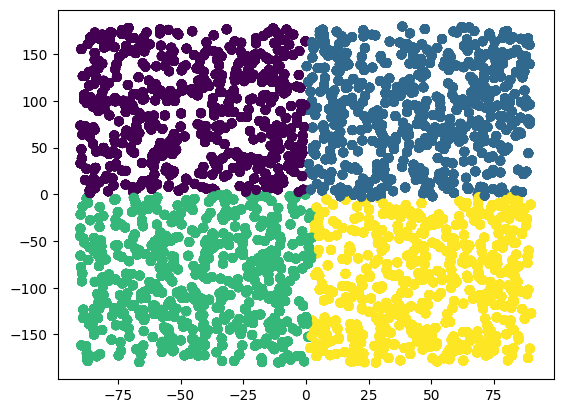

In [10]:
plt.scatter(x=df["Customer Location Latitude"], y=df["Customer Location Longitude"], c=df["K-Means"])
plt.show()

In [ ]:
""